# 01+02 — Data Loading, Cleaning & Augmentation (Merged Pipeline)

**Input:** `data/csv/` — Raw CIC-IDS2017 CSV files  
**Output:** `data/csv/cleaned_dataset.csv` — Cleaned & balanced dataset for 03_feature_engineering

## Correct Pipeline Order

| Step | Action | Rationale |
|------|--------|-----------|
| 1 | Load all raw CSV files & merge | Combined Dataset |
| 2 | Fix column names (strip whitespace) | Consistency |
| 3 | Remove extremely rare classes (Heartbleed, SQL Injection, Infiltration) | Insufficient samples |
| 4 | **Clean:** Drop Inf and NaN rows (NOT filled, directly dropped) | sklearn compatibility |
| 5 | **Clean:** Drop duplicate rows (feature-based, ignoring Label) | Overfitting prevention |
| 6 | **Sampling / Augmentation:** Balance classes on CLEAN data | Correct ordering avoids post-sampling data loss |
| 7 | Save final cleaned & balanced dataset | Input for 03_feature_engineering |

> **Methodological note:** Sampling/augmentation is applied *after* cleaning so that  
> the 30,000-row caps are enforced on clean data only — preventing class imbalance  
> caused by NaN/Inf/duplicate removal affecting sampled rows unevenly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import gc
import warnings

warnings.filterwarnings('ignore')

print("=" * 50)
print("✓ Libraries loaded")
print(f"  Pandas : {pd.__version__}")
print(f"  NumPy  : {np.__version__}")
print("=" * 50)

✓ Libraries loaded
  Pandas : 3.0.1
  NumPy  : 2.4.3


In [2]:
# ════════════════════════════════════════════════════════
# PLOT DIRECTORY STRUCTURE
# For consistent plot saving across all notebooks
# ════════════════════════════════════════════════════════
import os

PLOT_BASE = "../data/plots"

PLOT_DIRS = {
    "01_loading"  : os.path.join(PLOT_BASE, "01_loading"),
    "02_cleaning" : os.path.join(PLOT_BASE, "02_cleaning"),
    "03_features" : os.path.join(PLOT_BASE, "03_features"),
    "04_modeling" : os.path.join(PLOT_BASE, "04_modeling"),
    "05_xai"      : os.path.join(PLOT_BASE, "05_xai"),
    "06_fl"       : os.path.join(PLOT_BASE, "06_federated"),
}

for path in PLOT_DIRS.values():
    os.makedirs(path, exist_ok=True)

print("✓ Plot directory structure is ready:")
for k, v in PLOT_DIRS.items():
    print(f"   {v}/")

✓ Plot directory structure is ready:
   ../data/plots/01_loading/
   ../data/plots/02_cleaning/
   ../data/plots/03_features/
   ../data/plots/04_modeling/
   ../data/plots/05_xai/
   ../data/plots/06_federated/


In [3]:
csv_dir = "../data/csv"

# Expanded the list to exclude ALL previously generated files
EXCLUDE_PREFIXES = ("combined", "cleaned", "sampled", "featured", "label")

csv_files = sorted([
    f for f in os.listdir(csv_dir)
    if f.endswith(".csv") and not f.startswith(EXCLUDE_PREFIXES)
])

print(f"Found raw CSV files ({len(csv_files)} total):\n")
for f in csv_files:
    size_mb = os.path.getsize(os.path.join(csv_dir, f)) / (1024 * 1024)
    print(f"  {f:<65} ({size_mb:6.1f} MB)")

Found raw CSV files (8 total):

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  (  73.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv              (  73.3 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv                         (  55.6 MB)
  Monday-WorkingHours.pcap_ISCX.csv                                 ( 168.7 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv       (  79.3 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv            (  49.6 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv                                ( 128.8 MB)
  Wednesday-workingHours.pcap_ISCX.csv                              ( 214.7 MB)


In [4]:
# Cell 3 — Raw Data Exploration (EDA: Pre-Scan)
raw_summary = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)

    # Check column names (To resolve whitespace issues)
    # Read the first row and clean column names
    temp_cols = pd.read_csv(fpath, nrows=0).columns.str.strip()

    # Find the actual "Label" column name (Case-insensitive and ignoring whitespaces)
    actual_label_col = next((c for c in pd.read_csv(fpath, nrows=0).columns if c.strip() == "Label"), None)

    if actual_label_col is None:
        print(f"⚠ ERROR: 'Label' column not found in file {f}!")
        continue

    # Now read using the file-specific 'actual_label_col' name
    df_temp = pd.read_csv(fpath, usecols=[actual_label_col], encoding="utf-8", low_memory=False)

    # Standardization: Rename column to 'Label' and clean values
    df_temp.columns = ["Label"]
    df_temp["Label"] = df_temp["Label"].astype(str).str.strip()

    # Fix encoding corruption
    df_temp["Label"] = df_temp["Label"].replace({
        "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
        "Web Attack \ufffd XSS"          : "Web Attack - XSS",
        "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
    })

    counts = df_temp["Label"].value_counts().to_dict()
    total  = len(df_temp)
    benign = counts.get("BENIGN", 0)
    attack = total - benign

    raw_summary.append({
        "source_file"  : f,
        "total_rows"   : total,
        "benign_rows"  : benign,
        "attack_rows"  : attack,
        "label_counts" : counts,
    })

    print(f"✓ {f}")
    print(f"    Total: {total:>10,}  |  Benign: {benign:>10,}  |  Attack: {attack:>10,}")
    for label, cnt in sorted(counts.items(), key=lambda x: -x[1]):
        if label != "BENIGN":
            print(f"      └─ {label:<40} {cnt:>8,}")
    print()

    del df_temp
    gc.collect()

# Raw label distribution across all files
all_labels: dict[str, int] = {}
for row in raw_summary:
    for label, cnt in row["label_counts"].items():
        all_labels[label] = all_labels.get(label, 0) + cnt

print("=" * 60)
print("RAW CLASS DISTRIBUTION IN ALL DATA (pre-sampling)")
print("=" * 60)
for label, cnt in sorted(all_labels.items(), key=lambda x: -x[1]):
    bar = "█" * (cnt // 10000)
    print(f"  {label:<40} {cnt:>9,}  {bar}")

total_benign_raw = all_labels.get("BENIGN", 0)
total_attack_raw = sum(v for k, v in all_labels.items() if k != "BENIGN")
print(f"\n  Total BENIGN : {total_benign_raw:>9,}")
print(f"  Total ATTACK : {total_attack_raw:>9,}")
print(f"  Benign ratio  : %{total_benign_raw / (total_benign_raw + total_attack_raw) * 100:.1f}")

✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Total:    225,745  |  Benign:     97,718  |  Attack:    128,027
      └─ DDoS                                      128,027

✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Total:    286,467  |  Benign:    127,537  |  Attack:    158,930
      └─ PortScan                                  158,930

✓ Friday-WorkingHours-Morning.pcap_ISCX.csv
    Total:    191,033  |  Benign:    189,067  |  Attack:      1,966
      └─ Bot                                         1,966

✓ Monday-WorkingHours.pcap_ISCX.csv
    Total:    529,918  |  Benign:    529,918  |  Attack:          0

✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Total:    288,602  |  Benign:    288,566  |  Attack:         36
      └─ Infiltration                                   36

✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Total:    170,366  |  Benign:    168,186  |  Attack:      2,180
      └─ Web Attack - Brute Force             

## 🔬 PRE-AUGMENTATION BASELINE
> **Professor's request:** *"Results before the augmentation part"*  
> A baseline model is trained by loading **all data** from 7 days without applying any sampling (cap).  
> Then it is compared with the model after smart sampling (post-aug).  
> **Academic basis:** In CIC-IDS2017, the BENIGN/attack ratio is ~80%/20%; direct training produces misleading accuracy (R7, R14).

In [5]:
# PRE-AUG — All CSV files are loaded without cap (only label cleaning)
import gc
import warnings
warnings.filterwarnings('ignore')

# EXCLUDE_LABELS is not defined yet, so defining it here
_EXCLUDE = {"Heartbleed", "Web Attack - Sql Injection", "Infiltration"}
_META_COLS = {"Label", "source_file"}

print("PRE-AUG: Loading all CSV files without caps...\n")

pre_aug_parts = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)
    df_temp = pd.read_csv(fpath, encoding="utf-8", low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()

    if "Label" not in df_temp.columns:
        label_cols = [c for c in df_temp.columns if "label" in c.lower()]
        if label_cols:
            df_temp.rename(columns={label_cols[0]: "Label"}, inplace=True)
        else:
            print(f"  [SKIP] {f}: Label column not found")
            continue

    df_temp["source_file"] = f
    df_temp["Label"] = (
        df_temp["Label"].astype(str).str.strip()
        .replace({
            "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
            "Web Attack \ufffd XSS"          : "Web Attack - XSS",
            "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
        })
    )

    # Only remove problematic labels — NO sampling
    df_temp = df_temp[~df_temp["Label"].isin(_EXCLUDE)].copy()

    n_benign = (df_temp["Label"] == "BENIGN").sum()
    n_attack = len(df_temp) - n_benign
    print(f"  ✓ {f:<65} | Benign: {n_benign:>8,}  Attack: {n_attack:>7,}")

    pre_aug_parts.append(df_temp)
    del df_temp
    gc.collect()

df_pre_aug = pd.concat(pre_aug_parts, ignore_index=True)
del pre_aug_parts
gc.collect()

pre_label_dist = df_pre_aug["Label"].value_counts()
total_pre      = len(df_pre_aug)
benign_pre     = (df_pre_aug["Label"] == "BENIGN").sum()

print(f"\n{'='*60}")
print(f"PRE-AUG Total rows  : {total_pre:,}")
print(f"PRE-AUG Benign ratio  : %{benign_pre/total_pre*100:.1f}")
print(f"PRE-AUG Class count  : {pre_label_dist.shape[0]}")
print(f"{'='*60}")
print(pre_label_dist.to_string())

PRE-AUG: Loading all CSV files without caps...

  ✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                  | Benign:   97,718  Attack: 128,027
  ✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv              | Benign:  127,537  Attack: 158,930
  ✓ Friday-WorkingHours-Morning.pcap_ISCX.csv                         | Benign:  189,067  Attack:   1,966
  ✓ Monday-WorkingHours.pcap_ISCX.csv                                 | Benign:  529,918  Attack:       0
  ✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv       | Benign:  288,566  Attack:       0
  ✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv            | Benign:  168,186  Attack:   2,159
  ✓ Tuesday-WorkingHours.pcap_ISCX.csv                                | Benign:  432,074  Attack:  13,835
  ✓ Wednesday-workingHours.pcap_ISCX.csv                              | Benign:  440,031  Attack: 252,661

PRE-AUG Total rows  : 2,830,675
PRE-AUG Benign ratio  : %80.3
PRE-AUG Class count  : 12
Label
BENIGN   

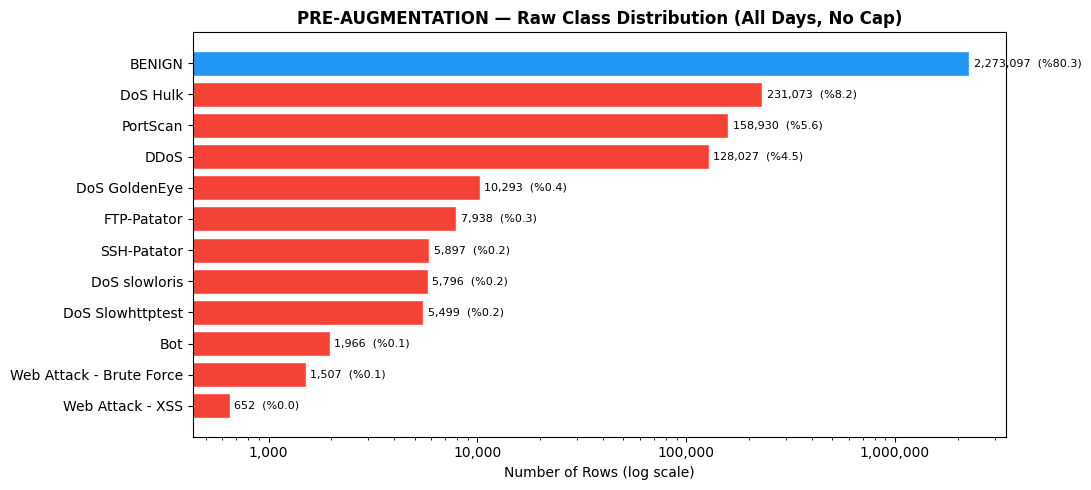

✓ Plot saved: ../data/plots/01_loading/pre_aug_class_distribution.png


In [6]:
# PRE-AUG — Class distribution plot
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(11, 5))
labels_p = pre_label_dist.index.tolist()
counts_p = pre_label_dist.values.tolist()
colors_p = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_p]

bars = ax.barh(labels_p[::-1], counts_p[::-1], color=colors_p[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Number of Rows (log scale)")
ax.set_title("PRE-AUGMENTATION — Raw Class Distribution (All Days, No Cap)",
             fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, cnt in zip(bars, counts_p[::-1]):
    pct = cnt / total_pre * 100
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}  (%{pct:.1f})", va="center", ha="left", fontsize=8)

plt.tight_layout()
save_path = os.path.join(PLOT_DIRS["01_loading"], "pre_aug_class_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Plot saved: {save_path}")

In [7]:
# PRE-AUG — LightGBM baseline model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
import sys
import subprocess

try:
    import lightgbm as lgb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    import lightgbm as lgb
import numpy as np

print("=" * 60)
print("PRE-AUG BASELINE MODEL TRAINING (LightGBM)")
print("=" * 60)

feature_cols_pre = [
    c for c in df_pre_aug.columns
    if c not in _META_COLS
    and pd.api.types.is_numeric_dtype(df_pre_aug[c])
]

X_pre = (
    df_pre_aug[feature_cols_pre]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .values
)

le_pre = LabelEncoder()
y_pre  = le_pre.fit_transform(df_pre_aug["Label"])

X_tr_pre, X_te_pre, y_tr_pre, y_te_pre = train_test_split(
    X_pre, y_pre,
    test_size=0.20,
    random_state=42,
    stratify=y_pre
)

print(f"  Train : {len(X_tr_pre):,} rows")
print(f"  Test  : {len(X_te_pre):,} rows")
print(f"  Feature count: {X_pre.shape[1]}")
print()

model_pre = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=63,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
model_pre.fit(X_tr_pre, y_tr_pre)
y_pred_pre = model_pre.predict(X_te_pre)

print("PRE-AUG Classification Report:\n")
print(classification_report(
    y_te_pre, y_pred_pre,
    target_names=le_pre.classes_,
    digits=4
))

macro_f1_pre    = f1_score(y_te_pre, y_pred_pre, average="macro")
weighted_f1_pre = f1_score(y_te_pre, y_pred_pre, average="weighted")
print(f"  Macro F1    : {macro_f1_pre:.4f}")
print(f"  Weighted F1 : {weighted_f1_pre:.4f}")

del X_pre, X_tr_pre, X_te_pre
gc.collect()
print("\n✓ PRE-AUG model ready. Now running pipeline cells...")

PRE-AUG BASELINE MODEL TRAINING (LightGBM)
  Train : 2,264,540 rows
  Test  : 566,135 rows
  Feature count: 78

PRE-AUG Classification Report:

                          precision    recall  f1-score   support

                  BENIGN     0.9461    0.9695    0.9576    454619
                     Bot     0.0000    0.0000    0.0000       393
                    DDoS     0.8765    0.6944    0.7749     25606
           DoS GoldenEye     0.0716    0.0389    0.0504      2059
                DoS Hulk     0.7311    0.7067    0.7187     46215
        DoS Slowhttptest     0.0000    0.0000    0.0000      1100
           DoS slowloris     0.5745    0.0699    0.1246      1159
             FTP-Patator     0.0000    0.0000    0.0000      1588
                PortScan     0.8950    0.9365    0.9153     31786
             SSH-Patator     0.0000    0.0000    0.0000      1179
Web Attack - Brute Force     0.0000    0.0000    0.0000       301
        Web Attack - XSS     0.0000    0.0000    0.0000       1

## ⚙️ MAIN PIPELINE — Step 1–3: Load All CSVs & Remove Rare Classes

All raw CSV files are loaded and merged into a single DataFrame.  
Column names are stripped and label encoding corruption is fixed.  
Extremely rare/mislabeled classes are removed **before** any cleaning or sampling.

In [8]:
RANDOM_STATE = 42

# ── Classes to Exclude (Rare / Incorrect Labels) ─────────────────────────────
# Heartbleed (11), Sql Injection (21), Infiltration (36):
# - Number of samples is insufficient to train the model
# - Infiltration label errors are documented in CIC-IDS2017 literature (R7, R14)
# - Leaving these classes artificially disrupts multiclass F1
EXCLUDE_LABELS = {
    "Heartbleed",
    "Web Attack - Sql Injection",
    "Infiltration",
}

print("Excluded classes:", EXCLUDE_LABELS)

Excluded classes: {'Web Attack - Sql Injection', 'Infiltration', 'Heartbleed'}


In [9]:
import os
import pandas as pd
import gc

raw_parts = []

for f in csv_files:
    fpath = os.path.join(csv_dir, f)

    # Read the entire file
    df_temp = pd.read_csv(fpath, encoding="utf-8", low_memory=False)

    # 1. Clean unnecessary whitespaces in column names
    df_temp.columns = df_temp.columns.str.strip()

    # 2. ERROR FIX: Safely find and rename the Label column
    if "Label" not in df_temp.columns:
        label_cols = [col for col in df_temp.columns if 'label' in col.lower()]
        if label_cols:
            df_temp.rename(columns={label_cols[0]: "Label"}, inplace=True)
        else:
            print(f"  [ERROR] Label column not found in {f}! Skipping...")
            continue

    df_temp["source_file"] = f  # Critical for source tracking

    # Label cleaning
    df_temp["Label"] = df_temp["Label"].astype(str).str.strip()
    df_temp["Label"] = df_temp["Label"].replace({
        "Web Attack \ufffd Brute Force" : "Web Attack - Brute Force",
        "Web Attack \ufffd XSS"          : "Web Attack - XSS",
        "Web Attack \ufffd Sql Injection": "Web Attack - Sql Injection",
    })

    # Step 3: Remove rare / erroneous classes BEFORE cleaning/sampling
    before_excl = len(df_temp)
    df_temp = df_temp[~df_temp["Label"].isin(EXCLUDE_LABELS)].copy()
    after_excl = len(df_temp)

    n_benign = (df_temp["Label"] == "BENIGN").sum()
    n_attack = len(df_temp) - n_benign
    print(f"✓ {f}")
    print(f"    Rows after rare class removal: {after_excl:,}  (removed {before_excl - after_excl:,})")
    print(f"    Benign: {n_benign:,}  |  Attack: {n_attack:,}")
    print()

    raw_parts.append(df_temp)
    del df_temp
    gc.collect()

df_combined_raw = pd.concat(raw_parts, ignore_index=True)
del raw_parts
gc.collect()

total_raw = len(df_combined_raw)
benign_raw = (df_combined_raw["Label"] == "BENIGN").sum()
print("=" * 65)
print("COMBINED DATASET (after rare class removal, before cleaning)")
print("=" * 65)
print(f"  Total rows      : {total_raw:>9,}")
print(f"  Benign rows     : {benign_raw:>9,}  ({benign_raw/total_raw*100:.1f}%)")
print(f"  Attack rows     : {total_raw-benign_raw:>9,}  ({(total_raw-benign_raw)/total_raw*100:.1f}%)")
print(f"  Column count    : {df_combined_raw.shape[1]}")
print()
print("Class distribution:")
for label, cnt in df_combined_raw["Label"].value_counts().items():
    pct = cnt / total_raw * 100
    print(f"  {label:<40} {cnt:>8,}  (%{pct:4.1f})")

✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Rows after rare class removal: 225,745  (removed 0)
    Benign: 97,718  |  Attack: 128,027

✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Rows after rare class removal: 286,467  (removed 0)
    Benign: 127,537  |  Attack: 158,930

✓ Friday-WorkingHours-Morning.pcap_ISCX.csv
    Rows after rare class removal: 191,033  (removed 0)
    Benign: 189,067  |  Attack: 1,966

✓ Monday-WorkingHours.pcap_ISCX.csv
    Rows after rare class removal: 529,918  (removed 0)
    Benign: 529,918  |  Attack: 0

✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Rows after rare class removal: 288,566  (removed 36)
    Benign: 288,566  |  Attack: 0

✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Rows after rare class removal: 170,345  (removed 21)
    Benign: 168,186  |  Attack: 2,159

✓ Tuesday-WorkingHours.pcap_ISCX.csv
    Rows after rare class removal: 445,909  (removed 0)
    Benign: 432,074  |  Attack: 13,

## 🧹 MAIN PIPELINE — Step 4–5: Data Cleaning on Raw Combined Data

Cleaning is applied **before** sampling so that the 30K caps are enforced on clean rows only.  
This prevents class imbalance caused by post-sampling removal of dirty rows.

### 4. NaN and Inf Analysis

In [10]:
print("=" * 55)
print("NaN ANALYSIS")
print("=" * 55)

missing = df_combined_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("✓ No NaN values")
else:
    print(f"Columns with NaN ({len(missing)} total):")
    for col, cnt in missing.items():
        pct = cnt / len(df_combined_raw) * 100
        print(f"  {col:<40} {cnt:>7,}  ({pct:.2f}%)")

print()
print("=" * 55)
print("INF ANALYSIS")
print("=" * 55)

numeric_cols = df_combined_raw.select_dtypes(include=[np.number]).columns.tolist()
inf_cols = {
    col: int(np.isinf(df_combined_raw[col]).sum())
    for col in numeric_cols
    if np.isinf(df_combined_raw[col]).sum() > 0
}

if not inf_cols:
    print("✓ No Inf values")
else:
    print(f"Columns with Inf ({len(inf_cols)} total):")
    for col, cnt in sorted(inf_cols.items(), key=lambda x: -x[1]):
        print(f"  {col:<40} {cnt:>7,}")

NaN ANALYSIS
Columns with NaN (1 total):
  Flow Bytes/s                               1,358  (0.05%)

INF ANALYSIS
Columns with Inf (2 total):
  Flow Packets/s                             2,867
  Flow Bytes/s                               1,509


### 4b. Inf → NaN → Drop Rows

**Rationale:** In CIC-IDS2017, NaN and Inf values usually originate from `Flow Bytes/s` and `Flow Packets/s`
columns; these columns occasionally produce division-by-zero artifacts.
Dropping these rows, which constitute 0.1–0.2% of the total data, is safer than interpolation
because they do not represent a real traffic flow.

In [11]:
before = len(df_combined_raw)

# Inf → NaN
df_combined_raw.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_rows = df_combined_raw.isnull().any(axis=1).sum()
print(f"Rows containing NaN after Inf → NaN: {nan_rows:,}")

# Drop NaN rows (NOT filled — directly dropped)
df_combined_raw.dropna(inplace=True)

after = len(df_combined_raw)
print(f"\nBefore cleaning : {before:>9,}")
print(f"After cleaning  : {after:>9,}")
print(f"Dropped rows    : {before-after:>9,}  ({(before-after)/before*100:.2f}%)")

print()
print("Class distribution after NaN/Inf cleaning:")
for label, cnt in df_combined_raw["Label"].value_counts().items():
    pct = cnt / len(df_combined_raw) * 100
    print(f"  {label:<40} {cnt:>8,}  ({pct:4.1f}%)")

Rows containing NaN after Inf → NaN: 2,867

Before cleaning : 2,830,675
After cleaning  : 2,827,808
Dropped rows    :     2,867  (0.10%)

Class distribution after NaN/Inf cleaning:
  BENIGN                                   2,271,320  (80.3%)
  DoS Hulk                                  230,124  ( 8.1%)
  PortScan                                  158,804  ( 5.6%)
  DDoS                                      128,025  ( 4.5%)
  DoS GoldenEye                              10,293  ( 0.4%)
  FTP-Patator                                 7,935  ( 0.3%)
  SSH-Patator                                 5,897  ( 0.2%)
  DoS slowloris                               5,796  ( 0.2%)
  DoS Slowhttptest                            5,499  ( 0.2%)
  Bot                                         1,956  ( 0.1%)
  Web Attack - Brute Force                    1,507  ( 0.1%)
  Web Attack - XSS                              652  ( 0.0%)


### 5. Duplicate Row Detection and Removal

**Rationale:** Multiple rows with the same feature vector push the model to overfitting.
Duplication check is performed on feature columns excluding `Label` and `source_file`;
identical feature vectors belonging to different classes are reported for label noise research.

In [12]:
print("=" * 60)
print("DUPLICATE ROW ANALYSIS")
print("=" * 60)

# Check only in feature columns
feature_cols = [c for c in df_combined_raw.columns if c not in ("Label", "source_file")]
n_dupes = df_combined_raw.duplicated(subset=feature_cols).sum()

print(f"Duplicate rows (feature-based): {n_dupes:,}")

if n_dupes > 0:
    dupe_mask = df_combined_raw.duplicated(subset=feature_cols, keep=False)
    by_label  = df_combined_raw[dupe_mask]["Label"].value_counts()
    print("Class distribution of duplicate rows:")
    for label, cnt in by_label.items():
        pct = cnt / n_dupes * 100
        print(f"  {label:<40} {cnt:>6,}  ({pct:4.1f}%)")

    before_d = len(df_combined_raw)
    df_combined_raw.drop_duplicates(subset=feature_cols, inplace=True)
    print(f"\n→ {before_d - len(df_combined_raw):,} duplicate rows dropped. Remaining: {len(df_combined_raw):,}")
else:
    print("✓ No duplicate rows")

print()
print("Class distribution after duplicate removal:")
for label, cnt in df_combined_raw["Label"].value_counts().items():
    pct = cnt / len(df_combined_raw) * 100
    print(f"  {label:<40} {cnt:>8,}  ({pct:4.1f}%)")

DUPLICATE ROW ANALYSIS
Duplicate rows (feature-based): 307,775
Class distribution of duplicate rows:
  BENIGN                                   236,485  (76.8%)
  PortScan                                 101,805  (33.1%)
  DoS Hulk                                 58,644  (19.1%)
  SSH-Patator                               2,826  ( 0.9%)
  FTP-Patator                               2,455  ( 0.8%)
  DoS slowloris                               508  ( 0.2%)
  DoS Slowhttptest                            323  ( 0.1%)
  Web Attack - Brute Force                     62  ( 0.0%)
  DDoS                                         22  ( 0.0%)
  DoS GoldenEye                                14  ( 0.0%)
  Bot                                          13  ( 0.0%)

→ 307,775 duplicate rows dropped. Remaining: 2,520,033

Class distribution after duplicate removal:
  BENIGN                                   2,094,458  (83.1%)
  DoS Hulk                                  172,749  ( 6.9%)
  DDoS                  

### 5b. Zero-Variance Column Analysis and Removal

**Rationale:** Columns where all values are zero or constant carry no discriminative information.
In CIC-IDS2017, bulk rate columns like `Bwd PSH Flags`, `Fwd Avg Bulk Rate` are known to be
zero across all rows (R7, R14). Dropping these columns early lightens the feature matrix
for subsequent notebooks.

In [13]:
numeric_cols = df_combined_raw.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 60)
print("ZERO-VARIANCE COLUMN ANALYSIS")
print("=" * 60)

# a) Completely zero
cols_all_zero = [c for c in numeric_cols if (df_combined_raw[c] == 0).all()]

# b) Constant value (single unique value even if not zero)
cols_zero_var = [c for c in numeric_cols if df_combined_raw[c].nunique() <= 1]
cols_const_nonzero = [c for c in cols_zero_var if c not in cols_all_zero]

to_drop = list(set(cols_all_zero + cols_zero_var))

print(f"All-zero columns ({len(cols_all_zero)} total):")
for c in sorted(cols_all_zero):
    print(f"  - {c}")

if cols_const_nonzero:
    print(f"\nConstant (non-zero) columns ({len(cols_const_nonzero)} total):")
    for c in sorted(cols_const_nonzero):
        print(f"  - {c}  (single value: {df_combined_raw[c].iloc[0]})")

print(f"\nTotal to drop: {len(to_drop)} columns")

before_cols = df_combined_raw.shape[1]
df_combined_raw.drop(columns=to_drop, inplace=True)
after_cols  = df_combined_raw.shape[1]
print(f"Columns: {before_cols} → {after_cols}  ({before_cols - after_cols} columns dropped)")
print(f"Remaining column count: {after_cols}")

ZERO-VARIANCE COLUMN ANALYSIS
All-zero columns (8 total):
  - Bwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bulk Rate
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk

Total to drop: 8 columns
Columns: 80 → 72  (8 columns dropped)
Remaining column count: 72


### 5c. High Sparsity Report (Info Only)

**Rationale:** Columns with a 50%+ zero ratio *can be discriminative* (e.g., flag counters
trigger in attack traffic, remain zero in benign). Therefore, they are only reported here,
not deleted. Feature selection decisions are left to `03_feature_engineering.ipynb`.

In [14]:
numeric_cols = df_combined_raw.select_dtypes(include=[np.number]).columns.tolist()
zero_pct     = (df_combined_raw[numeric_cols] == 0).mean() * 100
sparse_report = zero_pct[zero_pct > 50].sort_values(ascending=False)

print("=" * 70)
print("HIGH SPARSITY REPORT (50%+ zero ratio) — INFO ONLY")
print("These columns are NOT dropped → to be evaluated in 03_feature_engineering")
print("=" * 70)

if len(sparse_report) == 0:
    print("✓ No columns exceeding 50% threshold")
else:
    print(f"  {'Column':<45} {'Zero Ratio':>12}")
    print("-" * 60)
    for col, pct in sparse_report.items():
        print(f"  {col:<45} {pct:5.1f}%")
    print(f"\nTotal: {len(sparse_report)} columns")

HIGH SPARSITY REPORT (50%+ zero ratio) — INFO ONLY
These columns are NOT dropped → to be evaluated in 03_feature_engineering
  Column                                          Zero Ratio
------------------------------------------------------------
  CWE Flag Count                                100.0%
  Fwd URG Flags                                 100.0%
  RST Flag Count                                100.0%
  ECE Flag Count                                100.0%
  FIN Flag Count                                 96.8%
  SYN Flag Count                                 95.1%
  Fwd PSH Flags                                  95.1%
  Active Std                                     91.8%
  Idle Std                                       90.9%
  URG Flag Count                                 89.9%
  Active Max                                     77.8%
  Active Min                                     77.8%
  Active Mean                                    77.8%
  Idle Mean                           

## ⚙️ MAIN PIPELINE — Step 6: Sampling / Augmentation on CLEAN Data

The sampling strategy is now applied to the **already-cleaned** dataset.  
This guarantees that all 30,000-row caps are enforced on valid, clean rows only —  
no silent data loss due to post-hoc NaN/duplicate removal.

In [15]:
# ── Benign Parameters ────────────────────────────────────────────────────────
# Maximum number of benign rows to be taken from each source file.
# 50K × 8 files = max 400K benign → Monday monopoly is broken.
BENIGN_CAP_PER_FILE = 50_000

# ── Attack Parameters ────────────────────────────────────────────────────────
# Giant classes like DoS Hulk (231K), PortScan (159K), DDoS (128K)
# overwhelm other classes. This cap balances the classes below.
ATTACK_CAP_PER_CLASS = 30_000

print("Sampling Strategy:")
print(f"  Benign cap (per file)     : {BENIGN_CAP_PER_FILE:,}")
print(f"  Attack cap (per class)    : {ATTACK_CAP_PER_CLASS:,}")
print(f"  Excluded classes          : {EXCLUDE_LABELS}")
print(f"  Random state              : {RANDOM_STATE}")
print()
print("NOTE: Sampling is applied on the CLEANED dataset (NaN/Inf/duplicates already removed)")

Sampling Strategy:
  Benign cap (per file)     : 50,000
  Attack cap (per class)    : 30,000
  Excluded classes          : {'Web Attack - Sql Injection', 'Infiltration', 'Heartbleed'}
  Random state              : 42

NOTE: Sampling is applied on the CLEANED dataset (NaN/Inf/duplicates already removed)


In [16]:
sampled_parts = []

for src_file, file_df in df_combined_raw.groupby("source_file"):

    # ── BENIGN SAMPLING ──────────────────────────────────────────────────────
    benign_pool = file_df[file_df["Label"] == "BENIGN"]
    n_benign    = min(BENIGN_CAP_PER_FILE, len(benign_pool))
    benign_sample = benign_pool.sample(n=n_benign, random_state=RANDOM_STATE)

    # ── ATTACK SAMPLING (per-class cap) ──────────────────────────────────
    attack_pool  = file_df[file_df["Label"] != "BENIGN"]
    attack_parts = []

    for label, group in attack_pool.groupby("Label"):
        n_attack = min(ATTACK_CAP_PER_CLASS, len(group))
        attack_parts.append(group.sample(n=n_attack, random_state=RANDOM_STATE))

    attack_sample = pd.concat(attack_parts, ignore_index=True) if attack_parts else pd.DataFrame()

    # ── MERGE ────────────────────────────────────────────────────────────
    file_sampled = pd.concat([benign_sample, attack_sample], ignore_index=True)
    sampled_parts.append(file_sampled)

    print(f"✓ {src_file}")
    print(f"    Benign : {len(benign_pool):>8,} → sample {n_benign:>6,}")
    if attack_parts:
        for label, group in attack_pool.groupby("Label"):
            taken = min(ATTACK_CAP_PER_CLASS, len(group))
            capped = " (CAPPED)" if len(group) > ATTACK_CAP_PER_CLASS else ""
            print(f"    Attack [{label:<35}]: {len(group):>6,} → {taken:>6,}{capped}")
    else:
        print("    Attack : none")
    print()

df_combined = pd.concat(sampled_parts, ignore_index=True)
del sampled_parts
gc.collect()

# ── Class Distribution ───────────────────────────────────────────────────────
label_dist  = df_combined["Label"].value_counts()
source_dist = df_combined["source_file"].value_counts()

total_rows   = len(df_combined)
total_benign = (df_combined["Label"] == "BENIGN").sum()
total_attack = total_rows - total_benign

print("=" * 65)
print("COMBINED + CLEANED + SAMPLED DATASET SUMMARY")
print("=" * 65)
print(f"  Total rows      : {total_rows:>9,}")
print(f"  Total benign    : {total_benign:>9,}  ({total_benign/total_rows*100:.1f}%)")
print(f"  Total attack    : {total_attack:>9,}  ({total_attack/total_rows*100:.1f}%)")
print(f"  Column count    : {df_combined.shape[1]}")
print()

print("Class distribution:")
for label, cnt in label_dist.items():
    pct = cnt / total_rows * 100
    print(f"  {label:<40} {cnt:>8,}  (%{pct:4.1f})")

print()
print("Source file distribution:")
for src, cnt in source_dist.items():
    pct = cnt / total_rows * 100
    print(f"  {src:<65} {cnt:>7,}  (%{pct:4.1f})")

✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
    Benign :   95,068 → sample 50,000
    Attack [DDoS                               ]: 128,014 → 30,000 (CAPPED)

✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
    Benign :  121,560 → sample 50,000
    Attack [PortScan                           ]: 90,694 → 30,000 (CAPPED)

✓ Friday-WorkingHours-Morning.pcap_ISCX.csv
    Benign :  178,148 → sample 50,000
    Attack [Bot                                ]:  1,948 →  1,948

✓ Monday-WorkingHours.pcap_ISCX.csv
    Benign :  502,464 → sample 50,000
    Attack : none

✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
    Benign :  245,255 → sample 50,000
    Attack : none

✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
    Benign :  154,435 → sample 50,000
    Attack [Web Attack - Brute Force           ]:  1,470 →  1,470
    Attack [Web Attack - XSS                   ]:    652 →    652

✓ Tuesday-WorkingHours.pcap_ISCX.csv
    Benign :  400,833 → sample 50,000
 

## 8. Visualization — Cleaned & Sampled Dataset Distribution

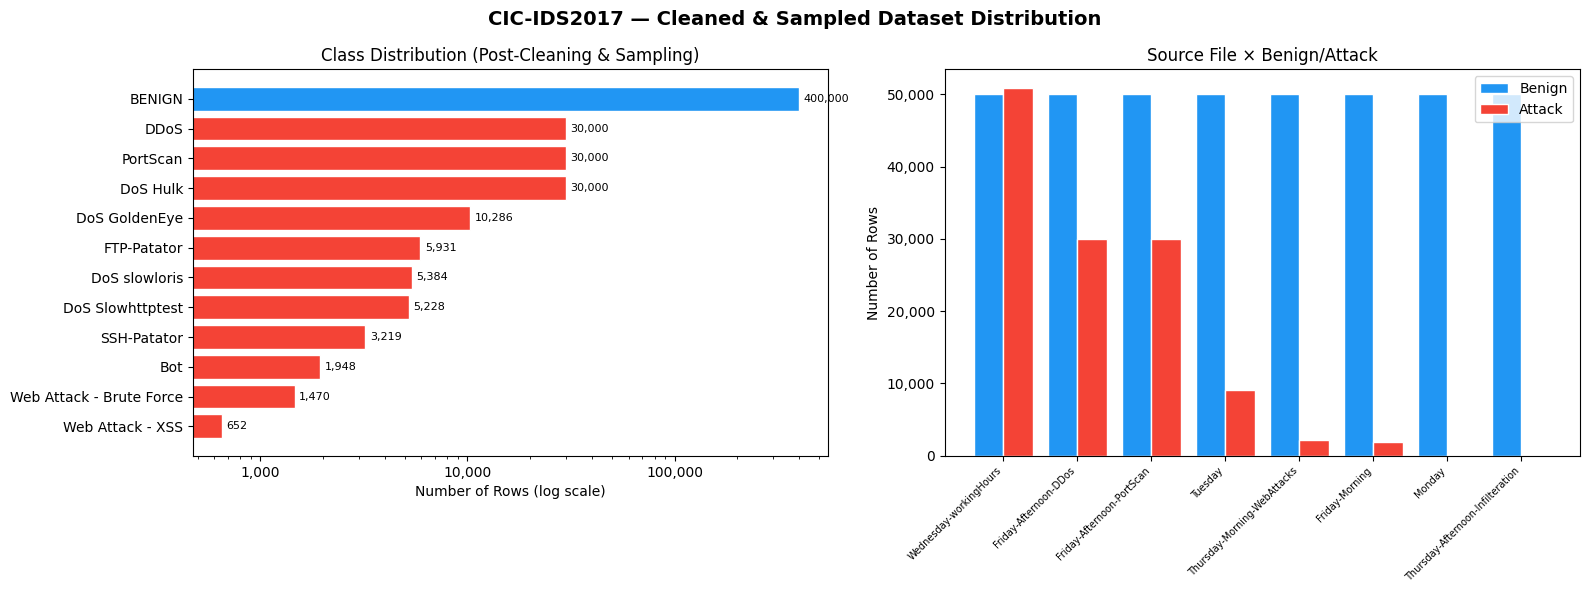

✓ Plot saved: ../data/plots/02_cleaning/cleaned_dataset_distribution.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("CIC-IDS2017 — Cleaned & Sampled Dataset Distribution", fontsize=14, fontweight="bold")

# ── Left: Class distribution (log scale) ─────────────────────────────────────
ax = axes[0]
labels_plot = label_dist.index.tolist()
counts_plot = label_dist.values.tolist()
colors      = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_plot]

bars = ax.barh(labels_plot[::-1], counts_plot[::-1], color=colors[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Number of Rows (log scale)")
ax.set_title("Class Distribution (Post-Cleaning & Sampling)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar, cnt in zip(bars, counts_plot[::-1]):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", ha="left", fontsize=8)

# ── Right: Source file × Benign/Attack ───────────────────────────────────────
ax = axes[1]
src_benign = df_combined[df_combined["Label"] == "BENIGN"]["source_file"].value_counts()
src_attack = df_combined[df_combined["Label"] != "BENIGN"]["source_file"].value_counts()

src_names_short = [
    s.replace("-WorkingHours", "").replace(".pcap_ISCX.csv", "")
    for s in source_dist.index
]

x = np.arange(len(source_dist))
w = 0.4
ax.bar(x - w/2, [src_benign.get(s, 0) for s in source_dist.index],
       w, label="Benign", color="#2196F3", edgecolor="white")
ax.bar(x + w/2, [src_attack.get(s, 0) for s in source_dist.index],
       w, label="Attack", color="#F44336", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(src_names_short, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Number of Rows")
ax.set_title("Source File × Benign/Attack")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()

plt.tight_layout()
save_path = os.path.join(PLOT_DIRS["02_cleaning"], "cleaned_dataset_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Plot saved: {save_path}")

## 9. Quality Control

Asserts prevent silent errors. Consistent with notebook 03's expectations.

In [18]:
print("=" * 60)
print("QUALITY CONTROL")
print("=" * 60)

# 1. No NaN
assert df_combined.isnull().sum().sum() == 0, "ERROR: NaN still present!"
print("✓ No NaN")

# 2. No Inf
numeric_cols_qc = df_combined.select_dtypes(include=[np.number]).columns
assert not np.isinf(df_combined[numeric_cols_qc].values).any(), "ERROR: Inf still present!"
print("✓ No Inf")

# 3. No rare/erroneous classes
found_excl = df_combined[df_combined["Label"].isin(EXCLUDE_LABELS)]["Label"].unique()
assert len(found_excl) == 0, f"ERROR: Rare/erroneous labels still present: {found_excl}"
print(f"✓ No rare/erroneous classes")

# 4. No encoding corruption
GARBAGE = {"Web Attack \ufffd Brute Force", "Web Attack \ufffd XSS"}
found_garb = df_combined[df_combined["Label"].isin(GARBAGE)]["Label"].unique()
assert len(found_garb) == 0, f"ERROR: Encoding corruption remains: {found_garb}"
print("✓ No encoding corruption")

# 5. Benign ratio is reasonable (40%–90%)
total     = len(df_combined)
n_benign  = (df_combined["Label"] == "BENIGN").sum()
benign_pct = n_benign / total * 100
assert 40 <= benign_pct <= 90, f"ERROR: Abnormal benign ratio → {benign_pct:.1f}%"
print(f"✓ Benign ratio is reasonable: {benign_pct:.1f}%")

# 6. Sufficient classes
n_classes = df_combined["Label"].nunique()
assert n_classes >= 5, f"ERROR: Insufficient classes: {n_classes}"
print(f"✓ Class count: {n_classes}")

# 7. Sufficient features
n_features = len(df_combined.select_dtypes(include=[np.number]).columns)
assert n_features >= 50, f"ERROR: Too few features left: {n_features}"
print(f"✓ Numeric feature count: {n_features}")

# 8. No zero-variance columns remain
zero_var_remaining = [c for c in numeric_cols_qc if df_combined[c].nunique() <= 1]
assert len(zero_var_remaining) == 0, f"ERROR: Zero-variance columns still present: {zero_var_remaining}"
print("✓ No zero-variance columns")

print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Rows         : {total:>9,}")
print(f"  Columns      : {df_combined.shape[1]}")
print(f"  Benign       : {n_benign:>9,}  ({benign_pct:.1f}%)")
print(f"  Attack       : {total-n_benign:>9,}  ({100-benign_pct:.1f}%)")
print(f"  Class count  : {n_classes}")
print()
print("=" * 60)
print("DATASET READY → next step: 03_feature_engineering.ipynb")
print("=" * 60)

QUALITY CONTROL
✓ No NaN
✓ No Inf
✓ No rare/erroneous classes
✓ No encoding corruption
✓ Benign ratio is reasonable: 76.3%
✓ Class count: 12
✓ Numeric feature count: 70
✓ No zero-variance columns

SUMMARY
  Rows         :   524,118
  Columns      : 72
  Benign       :   400,000  (76.3%)
  Attack       :   124,118  (23.7%)
  Class count  : 12

DATASET READY → next step: 03_feature_engineering.ipynb


## 10. Saving — Step 7: Export Cleaned & Balanced Dataset

The output file is named `cleaned_dataset.csv` — **identical to the original notebook 02 output path** —  
so that `03_feature_engineering.ipynb` reads it without any changes.

In [19]:
OUTPUT_PATH = "../data/csv/cleaned_dataset.csv"

df_combined.to_csv(OUTPUT_PATH, index=False)

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"✓ Cleaned dataset saved: {OUTPUT_PATH}")
print(f"  Size   : {size_mb:.1f} MB")
print(f"  Rows   : {len(df_combined):,}")
print(f"  Cols   : {df_combined.shape[1]}")

✓ Cleaned dataset saved: ../data/csv/cleaned_dataset.csv
  Size   : 188.4 MB
  Rows   : 524,118
  Cols   : 72


In [ ]:
# 11. EXTRA: Pre vs Post Augmentation Comparison Chart for Report
import matplotlib.pyplot as plt
import numpy as np
import os

# Tüm sınıfları al
all_classes = list(all_labels.keys())

# Öncesi ve Sonrası sayıları eşleştir
counts_pre = [all_labels.get(c, 0) for c in all_classes]
counts_post = [label_dist.get(c, 0) for c in all_classes]

# Grafik ayarları
x = np.arange(len(all_classes))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
rects1 = ax.bar(x - width/2, counts_pre, width, label='Raw Data (Pre-Cleaning & Aug)', color='lightgray', edgecolor='black')
rects2 = ax.bar(x + width/2, counts_post, width, label='Processed Data (Post-Cleaning & Aug)', color='#2196F3', edgecolor='black')

# Logaritmik skala
ax.set_yscale('log')
ax.set_ylabel('Number of Rows (Log Scale)')
ax.set_title('Class Distribution Comparison: Before vs. After Data Cleaning & Sampling', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_classes, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
save_path = os.path.join(PLOT_DIRS["01_loading"], "pre_vs_post_aug_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Comparison chart saved for the report: {save_path}")

⚠ HATA: Veri setinin yüklendiği üst hücreler çalıştırılmamış!
Lütfen notebook'u en üstten itibaren çalıştırın (Kernel -> Restart & Run All).
